In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the .dat file into a pandas DataFrame
df = pd.read_csv('types1.dat', comment='#', names=['A', 'U','M',"Swi6","Swi6M"])

# Plot c_R2[0] against TimeStep
plt.plot( df['A'], label ='A', color = 'b')
plt.plot( df['U'], label ='U', color = 'y')
plt.plot( df['M'], label ='M', color = 'r')
plt.legend()
plt.xlabel('TimeStep * $10^{-3}$')
plt.ylabel('Count type')
plt.title('Count type vs TimeStep Noise = 500 steps')
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'types1.dat'

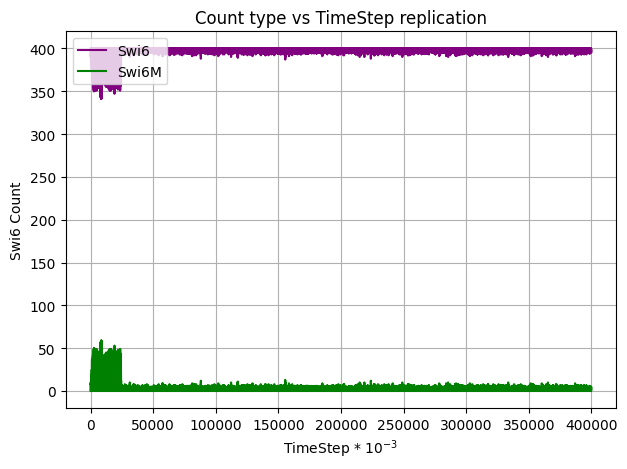

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotting the first dataset on ax1
ax1.plot(df['Swi6'], label='Swi6', color='purple')
ax1.set_xlabel('TimeStep * $10^{-3}$')
ax1.set_ylabel('Swi6 Count')


# Plotting the second dataset on the same axis
ax1.plot(df['Swi6M'], label='Swi6M', color='green')

# Adding title and grid
plt.title('Count type vs TimeStep replication')
fig.tight_layout()  # Adjust layout to prevent clipping

# Display legend
ax1.legend(loc='upper left')
plt.grid(True)
plt.show()


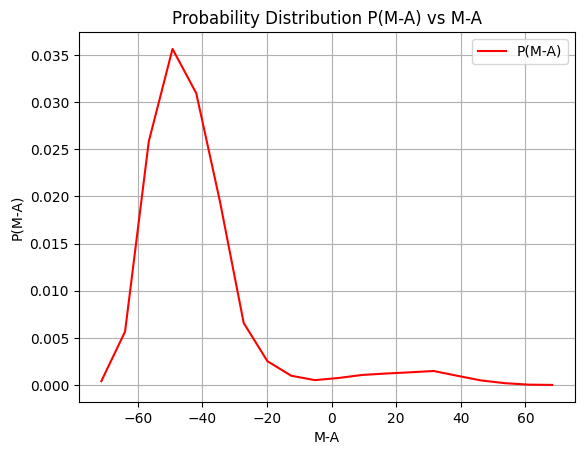

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# Calculate the histogram of 'M -A'
hist, bin_edges = np.histogram(df['M'] - df['A'], bins=20, density=True)  # You can adjust the number of bins

# The mid points of the bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot P(M) against M
plt.plot(bin_centers, hist, label='P(M-A)', color='r')
plt.legend()
plt.xlabel('M-A')
plt.ylabel('P(M-A)')
plt.title('Probability Distribution P(M-A) vs M-A')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Ensure df has the required columns
assert 'A' in df.columns and 'U' in df.columns and 'M' in df.columns, "DataFrame missing required columns."

# Remove mean values from each series
A_detrended = np.array(df['A']) - np.mean(df['A'])
U_detrended = np.array(df['U']) - np.mean(df['U'])
M_detrended = np.array(df['M']) - np.mean(df['M'])

# Perform Fourier transform
A_freq = fft(A_detrended)
U_freq = fft(U_detrended)
M_freq = fft(M_detrended)

# Get frequencies
freq = fftfreq(len(df['A']), (len(df['A'])))

# Only positive frequencies
positive_freq_indices = np.where(freq > 0)
positive_freq = freq[positive_freq_indices]

# Plotting the results
plt.figure(figsize=(12, 12))

# Plot A frequencies
plt.subplot(3, 1, 1)
plt.plot(positive_freq, np.abs(A_freq[positive_freq_indices]))
plt.title('Frequency components of A')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

# Plot U frequencies
plt.subplot(3, 1, 2)
plt.plot(positive_freq, np.abs(U_freq[positive_freq_indices]))
plt.title('Frequency components of U')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

# Plot M frequencies
plt.subplot(3, 1, 3)
plt.plot(positive_freq, np.abs(M_freq[positive_freq_indices]))
plt.title('Frequency components of M')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'scipy'

In [ ]:
# Extract the dominant frequency component for each series
dominant_freq_A = positive_freq[np.argmax(np.abs(A_freq[positive_freq_indices]))]
dominant_freq_U = positive_freq[np.argmax(np.abs(U_freq[positive_freq_indices]))]
dominant_freq_M = positive_freq[np.argmax(np.abs(M_freq[positive_freq_indices]))]

# Calculate power spectral density (PSD) for each series
psd_A = np.abs(A_freq[positive_freq_indices]) ** 2
psd_U = np.abs(U_freq[positive_freq_indices]) ** 2
psd_M = np.abs(M_freq[positive_freq_indices]) ** 2

# Summarize statistical properties of the frequency components
mean_freq_A = np.mean(np.abs(A_freq[positive_freq_indices]))
mean_freq_U = np.mean(np.abs(U_freq[positive_freq_indices]))
mean_freq_M = np.mean(np.abs(M_freq[positive_freq_indices]))

variance_freq_A = np.var(np.abs(A_freq[positive_freq_indices]))
variance_freq_U = np.var(np.abs(U_freq[positive_freq_indices]))
variance_freq_M = np.var(np.abs(M_freq[positive_freq_indices]))

# Example feature vector
feature_vector_A = [dominant_freq_A, mean_freq_A, variance_freq_A]
feature_vector_U = [dominant_freq_U, mean_freq_U, variance_freq_U]
feature_vector_M = [dominant_freq_M, mean_freq_M, variance_freq_M]
